In [36]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle



In [37]:
iris =  load_iris()
#carrega o dataset de flores

nums, features = iris.data.shape
# analise das features do dataset
print(nums)
print(features)
print(list(iris.target_names))

150
4
[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [38]:
X = iris.data
# dimensao do dataset
pca = PCA(n_components=4, whiten=True).fit(X)
# teste com transformando em 4 feaatures, mesmo sabendo que so há 4
X_pca = pca.transform(X)

In [39]:
print(pca.components_)

[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]
 [-0.58202985  0.59791083  0.07623608  0.54583143]
 [ 0.31548719 -0.3197231  -0.47983899  0.75365743]]


In [40]:
print(pca.explained_variance_ratio_)
# diferença de variamncia antes e depois do pca
print(sum(pca.explained_variance_ratio_))

[0.92461872 0.05306648 0.01710261 0.00521218]
1.0


In [41]:
features = iris.feature_names
features
#nome das features do dataset iris
# resultdo no grafico de barras ficoou ruim

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [42]:
names = ['PC1', 'PC2', 'PC3', 'PC4']

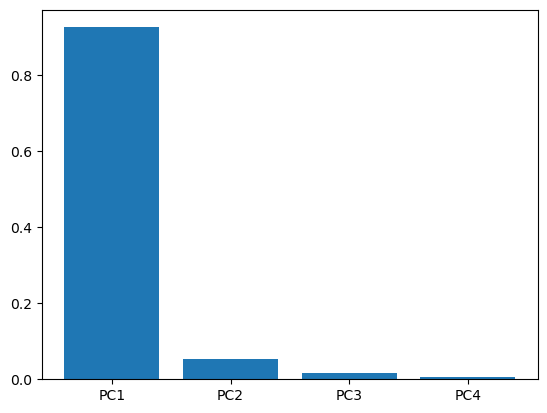

In [43]:
labels =[]
for i in pca.explained_variance_ratio_:
    labels.append(i)
pl.bar(names, labels)
pl.show()

### Podemos ver no grafico acima , que PC1 é que mais representa a variancia explicando quase tudo sozinha. 
### Isso justifica a escolha de 2 features do professor, a PC1 e PC2, elas explicam quase todo o dataset juntas.
### Essa demonstração foi feita com 4 variancias

/tmp/ipykernel_58598/700694507.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  pl.legend()


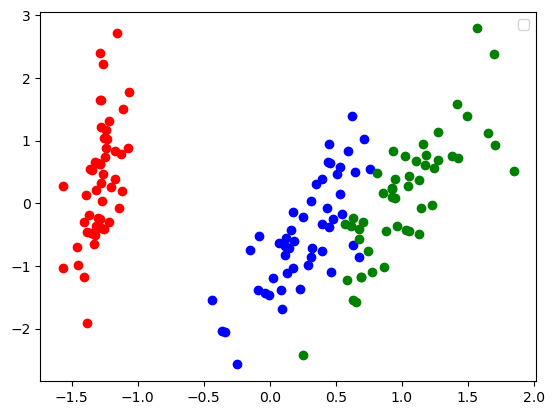

In [44]:
# cria um grafico de dispersão
colors = cycle('rbg')
target_ids = range(len(iris.target_names))
pl.figure()
for i, c, label in zip(target_ids, colors, iris.target_names):
    pl.scatter(X_pca[iris.target ==i, 0], X_pca[iris.target == i, 1], c=c)
pl.legend()
pl.show()